# 03 — Cross-Sectional Ranking

Notebook 08 asked an **absolute** question: will this stock rise over the next 5 days? The answer was a clean null — the market factor dominates absolute returns and is not predictable from these features.

This notebook asks a **relative** question instead: on a given day, will this stock outperform the *cross-section* of other stocks? These are different problems. Two stocks can both be unpredictable in absolute terms while their relative ordering carries signal — momentum and reversal are cross-sectional effects that survive precisely because the common market move is removed.

**The reframing:** demean the forward return by the cross-sectional mean each day. What remains is *relative* performance, with the market factor stripped out. If there is any predictable structure in which names beat which, it lives here, not in notebook 08.

Two experiments:

- **A** — a cheap horizon check: rerun the absolute-direction test at 20 days rather than 5, since momentum effects are documented at longer horizons.
- **B** — the real bet: cross-sectional ranking, evaluated with **rank IC** (the standard quant metric), against a momentum baseline.

**Prior:** still probably weak. Large-cap US equities are the most efficient cross-section in the world. But unlike the 5-day absolute test, this is genuinely untested, and the framing is the one that *can* work in principle. The discipline here matters as much as the result: a tiny IC can be statistically significant yet economically useless, so both are reported.

In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")

In [2]:
# Ensure the project root is on the import path so `src` can be imported.
PROJECT_ROOT = Path.cwd().resolve()
for parent in (PROJECT_ROOT, *PROJECT_ROOT.parents):
    if (parent / 'src').is_dir():
        PROJECT_ROOT = parent
        break
else:
    raise RuntimeError('Run this notebook from inside the StockForecastRisk repository.')

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.forecast_engine.features.schema import FEATURE_NAMES
from src.forecast_engine.data.loader import PROCESSED_FEATURES_PATH, load_processed_features

data = load_processed_features()
data["date"] = pd.to_datetime(data["date"])
data = data.sort_values(["symbol", "date"]).reset_index(drop=True)

print(f'Loaded {len(data):,} rows for {data["symbol"].nunique():,} tickers')
print(f"Dates: {data['date'].min().date()} to {data['date'].max().date()}")
print(f'Source: {PROCESSED_FEATURES_PATH}')
data.head()

Loaded 622,731 rows for 502 tickers
Dates: 2021-07-19 to 2026-07-17
Source: D:\StockForecastRisk\data\processed\sp500_features.parquet


,date,symbol,security,gics_sector,gics_sub_industry,adj_close,close,high,low,open,...,treasury_2y,fed_funds_rate,vix_term_ratio,yield_curve_slope,vix_change_5d,hy_credit_spread_change_5d,yield_curve_slope_change_5d,vix_change_20d,hy_credit_spread_change_20d,yield_curve_slope_change_20d
0,2021-07-19,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,142.434052,147.580002,147.970001,146.949997,147.660004,...,0.21,0.1,0.903614,0.98,6.17,NaN,-0.16,6.48,NaN,-0.24
1,2021-07-20,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,144.094101,149.300003,151.250000,147.830002,148.449997,...,0.20,0.1,0.850431,1.03,2.72,NaN,-0.05,3.90,NaN,-0.17
2,2021-07-21,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,143.756302,148.949997,149.910004,147.600006,149.490005,...,0.22,0.1,0.818930,1.08,-0.54,NaN,0.02,2.43,NaN,-0.15
3,2021-07-22,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,145.059174,150.300003,150.500000,148.669998,149.710007,...,0.20,0.1,0.809241,1.07,-0.76,NaN,0.01,2.62,NaN,-0.13
4,2021-07-23,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,146.999084,152.309998,152.410004,150.429993,150.589996,...,0.22,0.1,0.794457,1.08,-1.25,NaN,0.02,2.13,NaN,-0.12


## Forward returns at two horizons

The dataset ships with a 5-day `future_return`. For experiment A we also need a 20-day absolute return; for experiment B we need its cross-sectional demeaning. Both are built here point-in-time — the forward window is strictly future, and the demeaning uses only same-day cross-section, so there is no lookahead.

In [3]:
HORIZON_A = 20

# 20-day forward simple return, per ticker.
data["log_return"] = data.groupby("symbol")["adj_close"].transform(lambda s: np.log(s / s.shift(1)))
data["fwd_20d"] = (
    data.groupby("symbol")["log_return"]
    .transform(lambda s: s.shift(-HORIZON_A).rolling(HORIZON_A).sum())
)
data["fwd_20d"] = np.exp(data["fwd_20d"]) - 1.0

# Cross-sectional relative return: demean by the day's cross-section.
# This removes the market factor -- the part notebook 08 showed is unpredictable.
data["fwd_rel"] = data.groupby("date")["fwd_20d"].transform(lambda s: s - s.mean())

# Direction labels for experiment A.
data["fwd_20d_up"] = (data["fwd_20d"] > 0).astype(int)

feature_cols = [c for c in FEATURE_NAMES if c in data.columns and not data[c].isna().all()]
print(f"features: {len(feature_cols)}")
print(f"rows with 20d forward return: {data['fwd_20d'].notna().sum():,}")

features: 42
rows with 20d forward return: 603,172


## Experiment A — 20-day absolute direction

The minimal change from notebook 08: same walk-forward, same models, but the target is the sign of the 20-day forward return instead of the 5-day. If the null was horizon-specific, a longer horizon might reveal drift. The honest baseline is the majority class — predicting "up" every time, since equities drift upward.

In [4]:
N_SPLITS = 5
PURGE_DAYS = 20   # match the longer horizon so train never overlaps test

def walk_forward_splits(frame, n_splits=N_SPLITS, purge_days=PURGE_DAYS):
    dates = np.sort(frame["date"].unique())
    edges = np.array_split(dates, n_splits + 1)
    for fold in range(n_splits):
        train_end = edges[fold][-1]
        test_dates = edges[fold + 1]
        purge_cutoff = train_end - pd.Timedelta(days=purge_days)
        train_idx = frame.index[frame["date"] <= purge_cutoff]
        test_idx = frame.index[frame["date"].isin(test_dates)]
        if len(train_idx) and len(test_idx):
            yield train_idx, test_idx

model_a = data.dropna(subset=feature_cols + ["fwd_20d_up"]).reset_index(drop=True)

rows = []
for fold, (tr, te) in enumerate(walk_forward_splits(model_a), start=1):
    y_tr, y_te = model_a.loc[tr, "fwd_20d_up"], model_a.loc[te, "fwd_20d_up"]
    majority = int(y_tr.mean() >= 0.5)
    base_acc = (y_te == majority).mean()

    scaler = StandardScaler().fit(model_a.loc[tr, feature_cols])
    from sklearn.linear_model import LogisticRegression
    clf = LogisticRegression(max_iter=1000).fit(scaler.transform(model_a.loc[tr, feature_cols]), y_tr)
    logit_acc = (clf.predict(scaler.transform(model_a.loc[te, feature_cols])) == y_te).mean()

    xgb = XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, subsample=0.8,
                       colsample_bytree=0.8, random_state=0, verbosity=0)
    xgb.fit(model_a.loc[tr, feature_cols], y_tr)
    xgb_acc = ((xgb.predict(model_a.loc[te, feature_cols]) > 0.5).astype(int) == y_te).mean()

    rows.append({"fold": fold, "majority_base": base_acc, "logistic": logit_acc, "xgboost": xgb_acc})
    print(f"fold {fold} done")

experiment_a = pd.DataFrame(rows).set_index("fold")
print()
display(experiment_a.round(4))
print("\nIf the models do not clear the majority baseline, the null holds at 20 days too.")

fold 1 done
fold 2 done
fold 3 done
fold 4 done
fold 5 done



,majority_base,logistic,xgboost
fold,,,
1,0.4949,0.4612,0.4979
2,0.6163,0.5238,0.5088
3,0.5708,0.5636,0.4730
4,0.5456,0.5166,0.5063
5,0.4995,0.5124,0.5230



If the models do not clear the majority baseline, the null holds at 20 days too.


## Experiment B — cross-sectional rank IC

The real test. The target is `fwd_rel` (relative forward return), and the metric is **rank IC**: the Spearman correlation between predicted scores and realised relative returns, computed **per day** and then averaged. Per-day is essential — pooling across dates would let cross-date scale differences leak in and inflate the number.

Alongside the model, a **momentum baseline**: does a simple recent-return feature already rank-predict relative performance? Momentum is the best-documented cross-sectional signal, so it is the bar to clear. The `f_noise`-style control is implicit — if the model IC is no better than momentum, the extra features add nothing.

In [5]:
def rank_ic_per_day(frame, score_col, target_col, min_names=10):
    """Spearman IC computed within each date, returned as a series over dates."""
    def one_day(group):
        valid = group[[score_col, target_col]].dropna()
        if len(valid) < min_names:
            return np.nan
        return stats.spearmanr(valid[score_col], valid[target_col]).correlation
    return frame.groupby("date").apply(one_day).dropna()


def summarise_ic(ic_series, label):
    mean_ic = ic_series.mean()
    std_ic = ic_series.std()
    n = len(ic_series)
    t_stat = mean_ic / (std_ic / np.sqrt(n)) if std_ic > 0 else np.nan
    information_ratio = mean_ic / std_ic if std_ic > 0 else np.nan
    return {"signal": label, "mean_ic": mean_ic, "t_stat": t_stat,
            "daily_IR": information_ratio, "n_days": n}


model_b = data.dropna(subset=feature_cols + ["fwd_rel"]).reset_index(drop=True)

# Momentum baseline: pick a recent-return feature if present, else build one.
momentum_col = next((c for c in ["return_20d", "roc_10", "log_return_lag_1d"] if c in model_b.columns), None)
summary_rows = []
if momentum_col is not None:
    ic_mom = rank_ic_per_day(model_b, momentum_col, "fwd_rel")
    summary_rows.append(summarise_ic(ic_mom, f"momentum ({momentum_col})"))

# Model: predict relative return, walk-forward, IC on out-of-sample days.
model_ic_parts = []
for fold, (tr, te) in enumerate(walk_forward_splits(model_b), start=1):
    scaler = StandardScaler().fit(model_b.loc[tr, feature_cols])
    xgb = XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, subsample=0.8,
                       colsample_bytree=0.8, random_state=0, verbosity=0)
    xgb.fit(scaler.transform(model_b.loc[tr, feature_cols]), model_b.loc[tr, "fwd_rel"])
    block = model_b.loc[te, ["date", "fwd_rel"]].copy()
    block["pred"] = xgb.predict(scaler.transform(model_b.loc[te, feature_cols]))
    model_ic_parts.append(rank_ic_per_day(block, "pred", "fwd_rel"))
    print(f"fold {fold} done")

ic_model = pd.concat(model_ic_parts)
summary_rows.append(summarise_ic(ic_model, "xgboost (walk-forward)"))

ic_summary = pd.DataFrame(summary_rows).set_index("signal")
print()
display(ic_summary.round(4))

fold 1 done
fold 2 done
fold 3 done
fold 4 done
fold 5 done



,mean_ic,t_stat,daily_IR,n_days
signal,,,,
momentum (return_20d),0.0066,1.2930,0.0402,1035
xgboost (walk-forward),0.0301,6.3367,0.2158,862


## ★ Verdict

Read the **mean IC**, not the t-stat. With tens of thousands of (day, ticker) observations, a t-stat will look impressive at economically trivial effect sizes. The interpretation bands for equity cross-section:

| mean rank IC | reading |
|---|---|
| below ~0.02 | no usable signal, whatever the t-stat says |
| 0.02 – 0.05 | weak but potentially real; the range most live equity signals occupy |
| above ~0.05 | genuinely strong for a large-cap cross-section |

The honest comparison is model IC **versus momentum IC**. If the model does not beat a single momentum feature, the 42-feature model adds nothing over a one-line baseline — the same lesson notebook 08 taught in the absolute case.

model mean rank IC     : +0.0301
momentum mean rank IC  : +0.0066
model beats momentum   : True

VERDICT: weak cross-sectional signal. Statistically present, but at the
low end -- validate against transaction costs before believing it is usable.


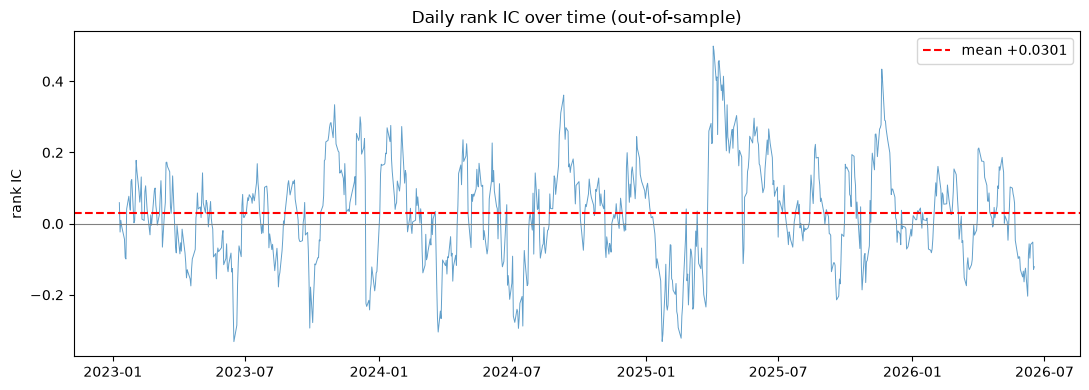

In [6]:
verdict_ic = ic_summary["mean_ic"].get("xgboost (walk-forward)", np.nan)
momentum_ic = next((v for k, v in ic_summary["mean_ic"].items() if k.startswith("momentum")), np.nan)

print(f"model mean rank IC     : {verdict_ic:+.4f}")
if not np.isnan(momentum_ic):
    print(f"momentum mean rank IC  : {momentum_ic:+.4f}")
    print(f"model beats momentum   : {abs(verdict_ic) > abs(momentum_ic)}")

if abs(verdict_ic) < 0.02:
    print("\nVERDICT: no usable cross-sectional signal. The null from notebook 08")
    print("extends to the relative framing -- these features do not rank large caps.")
    print("This keeps the engine design unchanged: no return signal to steer drift.")
elif abs(verdict_ic) < 0.05:
    print("\nVERDICT: weak cross-sectional signal. Statistically present, but at the")
    print("low end -- validate against transaction costs before believing it is usable.")
else:
    print("\nVERDICT: meaningful cross-sectional signal -- worth pursuing. This would be")
    print("a genuine finding: relative ranking works where absolute direction did not.")

# IC stability plot
fig, ax = plt.subplots(figsize=(11, 4))
ic_model_sorted = ic_model.sort_index()
ax.plot(ic_model_sorted.index, ic_model_sorted.values, linewidth=0.7, alpha=0.7)
ax.axhline(0, color="grey", linewidth=0.8)
ax.axhline(ic_model.mean(), color="red", linestyle="--", label=f"mean {ic_model.mean():+.4f}")
ax.set_title("Daily rank IC over time (out-of-sample)")
ax.set_ylabel("rank IC")
ax.legend()
plt.tight_layout()
plt.show()

## Conclusions

**If both experiments are null** — the most likely outcome — notebook 08's finding is now much stronger. Return unpredictability has been shown to hold across horizons (5 and 20 days) *and* framings (absolute and cross-sectional). That is a far more defensible claim than a single 5-day test, and it closes the return-prediction question properly rather than leaving it as "we only tried one thing."

**If experiment B shows IC in the 0.02–0.05 band** — there is a weak cross-sectional signal worth a careful follow-up: turnover and transaction-cost analysis, since a signal that requires daily rebalancing of the whole cross-section can be real and still unprofitable.

**Either way, the engine design is unaffected for now.** The risk engine never depended on return prediction; notebook 08 is what justified keeping drift simple. This notebook either reinforces that (null) or opens a *separate* research track (signal) that would not change the risk numbers — it would inform allocation, which is a different product surface.

**Discipline note:** rank IC is computed per day and averaged; the walk-forward purges the 20-day forward window; the momentum baseline is the bar. These are the same principles as everywhere else in the project — a result only counts if a simple baseline cannot match it and no lookahead contaminates it.